## 1-Data Loading and Overview

# Introduction

This notebook prepares the activity-level dataset for subsequent machine learning analyses within the synthetic program evaluation framework developed for this DBA research project.

The objective is to organize the activity-level data into a structured dataset suitable for later analyses. The dataset combines activity characteristics, project context, partner information, volunteer characteristics, and credibility scores (CS), which indicate the confidence associated with each evaluation dimension.

This preparation stage focuses on selecting the variables used for analysis and standardizing the numerical features required for clustering. Rather than improving predictive performance, it prepares a consistent analytical dataset for the subsequent activity-level analyses, particularly clustering and exploratory pattern identification.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Lists is excluded because it only contains UI dropdown reference values
# and does not represent analytical or machine learning–relevant data.

file_path = "/kaggle/input/datasets/jfjutras07/data-activity-dataset/5-Data_Activity_Dataset.xlsx"

xls = pd.ExcelFile(file_path)
sheet_names = [s for s in xls.sheet_names if s != "Lists"]

dataframes = {}

for sheet in sheet_names:
    dataframes[sheet] = pd.read_excel(xls, sheet_name=sheet)

overview = pd.DataFrame({
    "table_name": sheet_names,
    "n_rows": [dataframes[s].shape[0] for s in sheet_names],
    "n_cols": [dataframes[s].shape[1] for s in sheet_names]
})

overview

,table_name,n_rows,n_cols
0,Activity_FE,196,21


In [2]:
import sys

# Load custom library from GitHub
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
sys.path.append("/kaggle/working/jfj-utils")

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3532, done.
remote: Counting objects: 100% (292/292), done.
remote: Compressing objects: 100% (193/193), done.
remote: Total 3532 (delta 232), reused 99 (delta 99), pack-reused 3240 (from 4)
Receiving objects: 100% (3532/3532), 1.19 MiB | 7.54 MiB/s, done.
Resolving deltas: 100% (2323/2323), done.


## 2-Data Preparation

Variables are organized according to their analytical role, relevant numerical variables are selected for clustering, and the selected features are standardized to prepare the dataset for distance-based analyses.

In [3]:
# Dataframe naming
df_activity = dataframes["Activity_FE"].copy()

In [4]:
# Variable groups

# Identifiers (not used for clustering)
id_cols = [
    "id_activity",
    "id_project"
]

# Contextual variables (not used for clustering in this step)
context_cols = [
    "activity_type",
    "deliverable_associated",
    "project_type",
    "project_class",
    "age_group",
    "gender",
    "origin",
    "education",
    "previous_mandates"
]

# Numeric variables (potential inputs for analysis)
numeric_cols = [
    "organization_size",
    "years_collaboration",
    "cost",
    "time",
    "novelty",
    "effort",
    "CS_cost",
    "CS_time",
    "CS_novelty",
    "CS_effort"
]

In [5]:
# Keep only variables used for clustering (operational view only)

clustering_cols = ["cost", "time", "novelty", "effort"]

df_cluster = df_activity[clustering_cols].dropna()

In [6]:
from sklearn.preprocessing import StandardScaler

# Standardization ensures that all numerical variables contribute equally
# to the distance calculations used by clustering algorithms.

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df_cluster),
    columns=clustering_cols
)

## 3-Activity-Level Evidence Credibility Assessment

This section summarizes the credibility scores (CS) associated with the activity-level evaluation dimensions. These scores indicate the confidence associated with each simulated evaluation and provide additional context for interpreting the analytical results. Higher credibility scores indicate stronger supporting evidence, while lower scores suggest that the corresponding evaluations should be interpreted more cautiously.

In [7]:
cs_cols = ["CS_cost", "CS_time", "CS_novelty", "CS_effort"]

cs_summary = df_activity[cs_cols].describe().T

cs_mean = df_activity[cs_cols].mean().sort_values(ascending=False)

print("\n" + "="*60 + "\n")
print("Credibility Scores Summary (Descriptive Statistics)")
print("\n")
print(cs_summary)

print("\n" + "="*60 + "\n")
print("Average Credibility Scores by Dimension")
print("\n")
print(cs_mean)

print("\n" + "="*60 + "\n")



Credibility Scores Summary (Descriptive Statistics)


            count      mean       std  min  25%  50%  75%  max
CS_cost     196.0  3.178571  1.115738  1.0  2.0  3.0  4.0  5.0
CS_time     196.0  1.775510  0.939510  1.0  1.0  1.0  2.0  4.0
CS_novelty  196.0  2.933673  1.228169  1.0  2.0  3.0  4.0  5.0
CS_effort   196.0  1.734694  0.877654  1.0  1.0  1.0  2.0  4.0


Average Credibility Scores by Dimension


CS_cost       3.178571
CS_novelty    2.933673
CS_time       1.775510
CS_effort     1.734694
dtype: float64




### Summary Table

| Evidence Group                    | Dimensions    | Mean Score | Evidence Profile                                                                                           | Analytical Implication                                                                                               |
| --------------------------------- | ------------- | ---------: | ---------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Moderate documentary evidence** | Cost, Novelty |      ≈ 3.0 | Generally supported by at least one formal source, with occasional corroboration from additional evidence. | These dimensions provide a moderate level of confidence for subsequent analyses.                                     |
| **Limited documentary evidence**  | Time, Effort  |      ≈ 1.8 | Primarily supported by isolated or limited low-level evidence, with little formal corroboration.           | Results involving these dimensions should be interpreted with greater caution due to higher documentary uncertainty. |


These results provide additional context for the activity-level analyses presented in the final notebook. They will also support the discussion of how stronger supporting evidence could improve the reliability of future evaluations.

## 4-Activity Clustering

This section explores the structure of the activity dataset using unsupervised learning techniques. Unlike supervised methods, clustering does not rely on predefined labels. Instead, it groups activities according to similarities in their operational characteristics (cost, time, novelty, and effort).

The objective is to identify activity profiles that reflect different levels of operational demands. These profiles are explored descriptively and will later be interpreted using the contextual variables that were not included in the clustering process.

Several clustering algorithms are compared because each partitions the data differently. Their performance is evaluated using the Silhouette score to identify the solution that provides the best balance between cluster cohesion and separation.

In [8]:
from modeling.clustering_models import compare_clustering_models

clustering_cols = ["cost", "time", "novelty", "effort"]

models = {}

for k in [3, 4, 5]:
    print(f"\n==================== K = {k} ====================\n")
    
    models[k] = compare_clustering_models(
        df=df_activity[clustering_cols].dropna(),
        predictors=clustering_cols,
        k=k,
        optimize=False
    )


==================== K = 3 ====================

Starting Clustering Comparison | Predictors: 4
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
0,Agglomerative,3,0.1807
3,GMM,3,0.1801
1,BIRCH,3,0.1786
4,KMeans,3,0.1739
2,DBSCAN,11,-0.0355



==================== K = 4 ====================

Starting Clustering Comparison | Predictors: 4
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
4,KMeans,4,0.1821
0,Agglomerative,4,0.1670
3,GMM,4,0.1620
1,BIRCH,4,0.1546
2,DBSCAN,11,-0.0355



==================== K = 5 ====================

Starting Clustering Comparison | Predictors: 4
---------------------------------------------

--- Final Clustering Comparison (Sorted by Silhouette) ---


,Model,Clusters,Silhouette
4,KMeans,5,0.1792
0,Agglomerative,5,0.1636
1,BIRCH,5,0.1550
3,GMM,5,0.1470
2,DBSCAN,11,-0.0355


Although the Silhouette scores are similar across the tested solutions, the four-cluster solution provides the highest overall score while remaining easy to interpret. The value of k = 4 was therefore selected for the subsequent analyses.


--- Clustering Performance Check ---
Model                     : KMeans
Number of Clusters         : 4
Silhouette Score           : 0.1821  (Goal: -> 1.0)
Calinski-Harabasz Index    : 42.10 (Goal: High)
Davies-Bouldin Index       : 1.7302  (Goal: -> 0.0)
---------------------------------------------
Status: WEAK. Poorly defined clusters; high risk of overlap.
---------------------------------------------


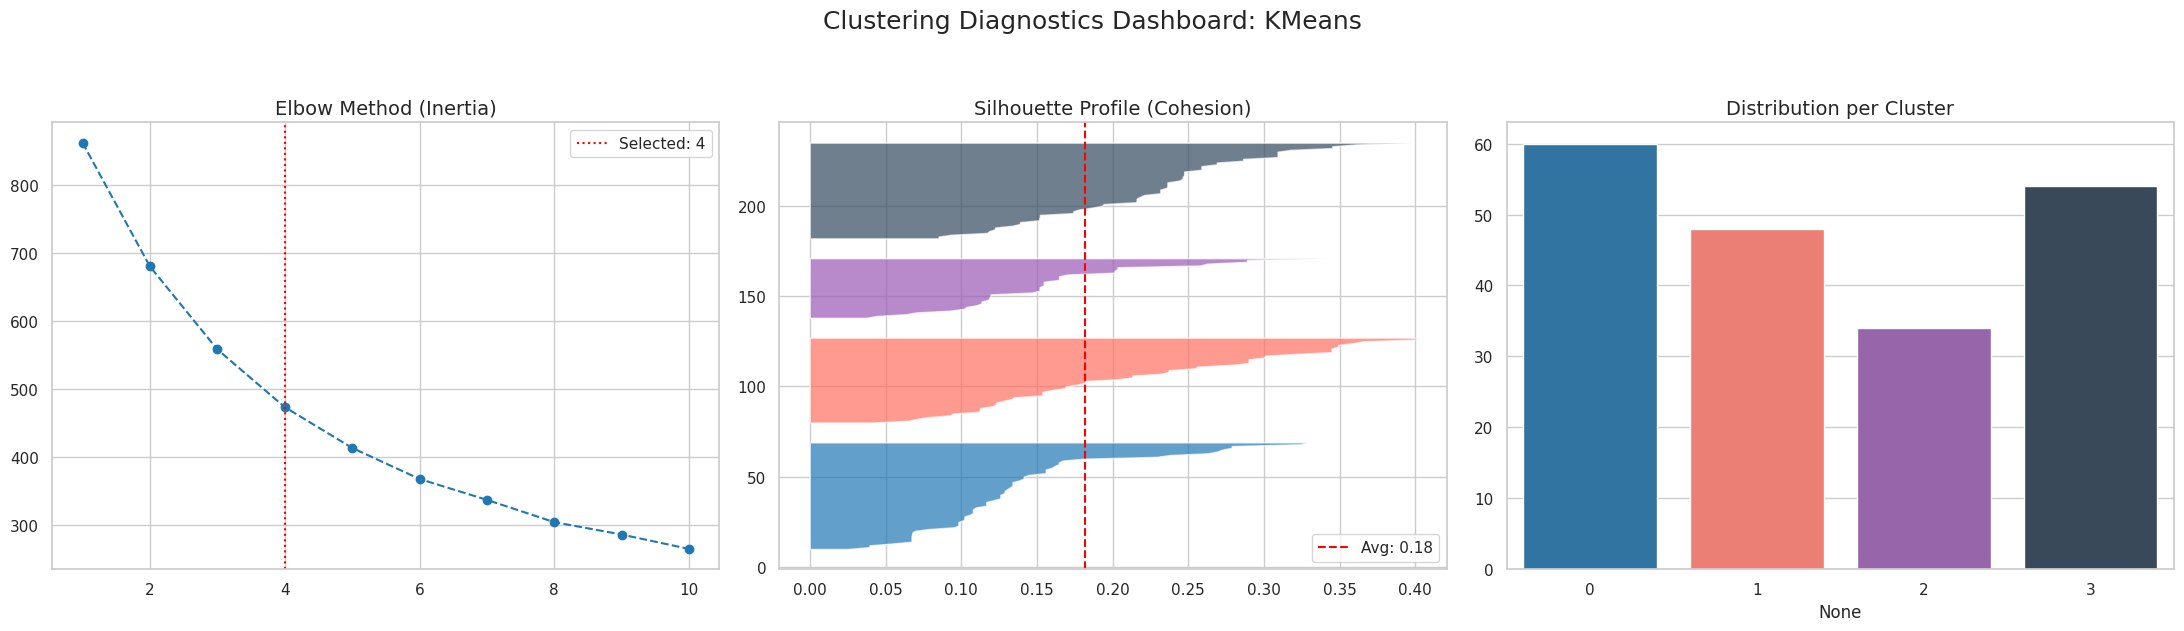

{'silhouette': np.float64(0.18211765682016587),
 'calinski_harabasz': np.float64(42.10369305826606),
 'davies_bouldin': np.float64(1.730169689655416),
 'n_clusters': 4}

In [9]:
from visualization.explore_clusters import plot_cluster_diagnostics

best_k = 4

# Extract KMeans model for the selected number of clusters
kmeans_model = models[best_k]["KMeans"]

# Generate cluster labels for visualization
labels = kmeans_model.fit_predict(df_cluster)

# Plot clustering diagnostics to evaluate cluster quality and separation
plot_cluster_diagnostics(
    df_scaled=df_cluster,
    labels=labels,
    model_name="KMeans"
)

The clustering results show weakly defined groups with limited separation between clusters, which is consistent with the synthetic nature of the dataset. The objective at this stage is not to obtain highly distinct clusters, but to validate the analytical workflow before applying it to real-world evaluation data, where stronger structures may emerge.

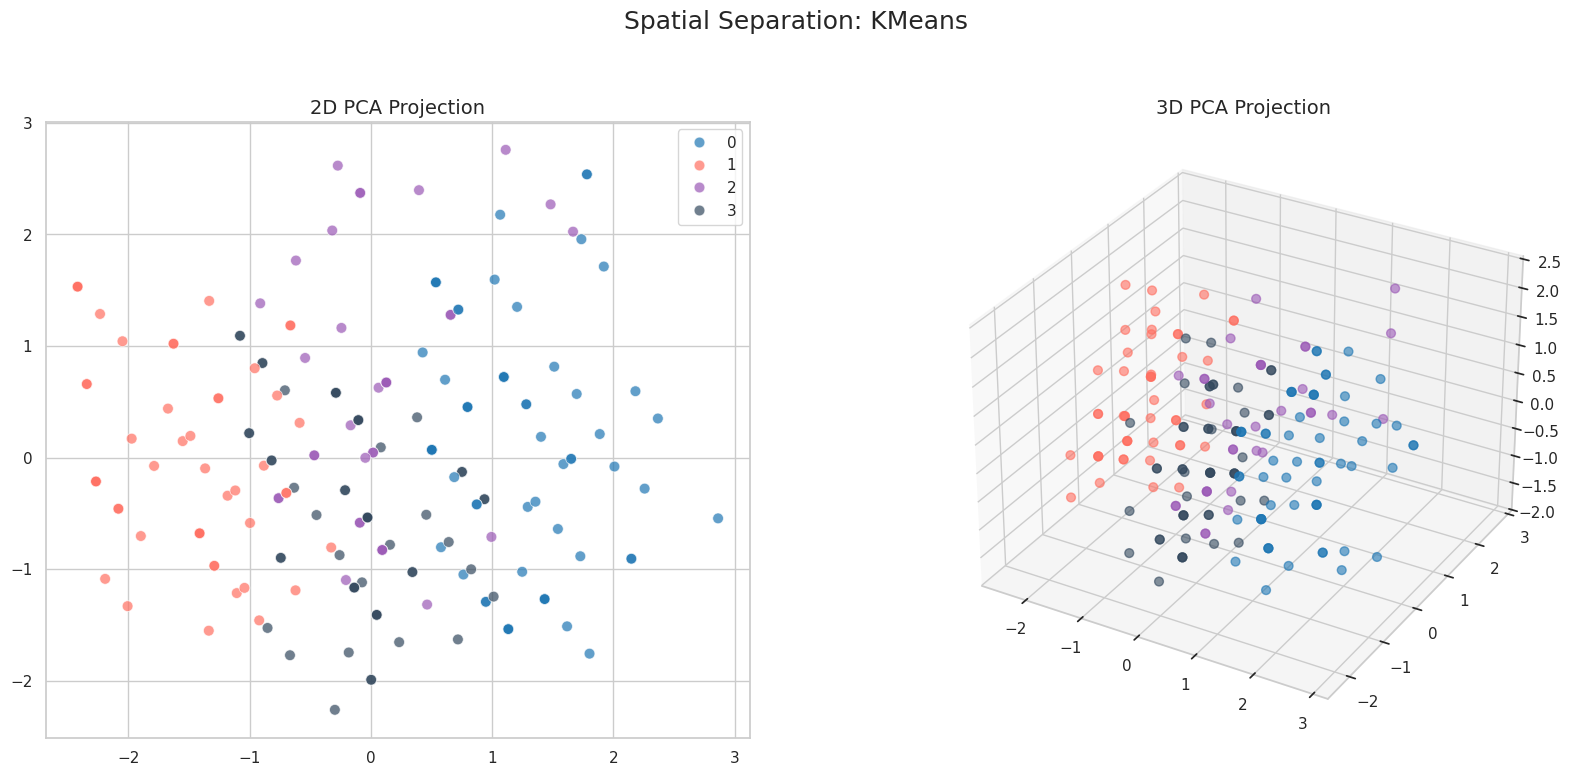

In [10]:
from visualization.explore_clusters import plot_cluster_projections, plot_cluster_radar_charts
plot_cluster_projections(df_cluster, labels, "KMeans")

In [11]:
from modeling.model_stability import check_clustering_model_stability

# Run stability analysis on the selected clustering model
stability_results = check_clustering_model_stability(
    model=kmeans_model,
    df=df_activity,
    predictors=clustering_cols,
    seeds=[0, 21, 42, 84],
    subsample_frac=0.8
)

stability_results


--- Clustering Algorithmic Stability Check ---
Model Class              : KMeans
Seeds Evaluated           : [0, 21, 42, 84]
Subsample Fraction        : 0.8
--------------------------------------------------
Random Initialization Stability (ARI):
  ARI(seed 0 vs 21) = 1.000
  ARI(seed 0 vs 42) = 1.000
  ARI(seed 0 vs 84) = 1.000
  Mean ARI (seeds)        = 1.000
--------------------------------------------------
Subsampling Stability (ARI):
  ARI(subsample run 1) = 0.377
  ARI(subsample run 2) = 0.373
  ARI(subsample run 3) = 0.761
  Mean ARI (subsampling)  = 0.504
--------------------------------------------------
Status: MODERATELY STABLE. Minor sensitivity detected.
--------------------------------------------------


{'ari_seeds_mean': np.float64(1.0),
 'ari_subsampling_mean': np.float64(0.5035350837633077),
 'ari_overall_mean': np.float64(0.7517675418816538),
 'ari_seeds': [1.0, 1.0, 1.0],
 'ari_subsampling': [0.376896400444057,
  0.3727430167020723,
  0.7609658341437938]}

The KMeans solution is fully stable across different random initializations (ARI = 1.00), indicating that the algorithm consistently converges to the same clustering solution. Stability decreases when different subsamples are used (mean ARI ≈ 0.50), suggesting that the identified clusters are moderately influenced by the composition of the simulated dataset. This behaviour is consistent with the exploratory objective of the analysis and the controlled nature of the simulated data.

## 5-Cluster Analysis

The clusters are described according to their operational characteristics (cost, time, novelty, and effort), their distribution across activity types and project contexts, and the associated credibility scores. The objective is to provide an interpretable description of the different activity profiles observed in the simulated dataset before using these profiles in subsequent analyses.

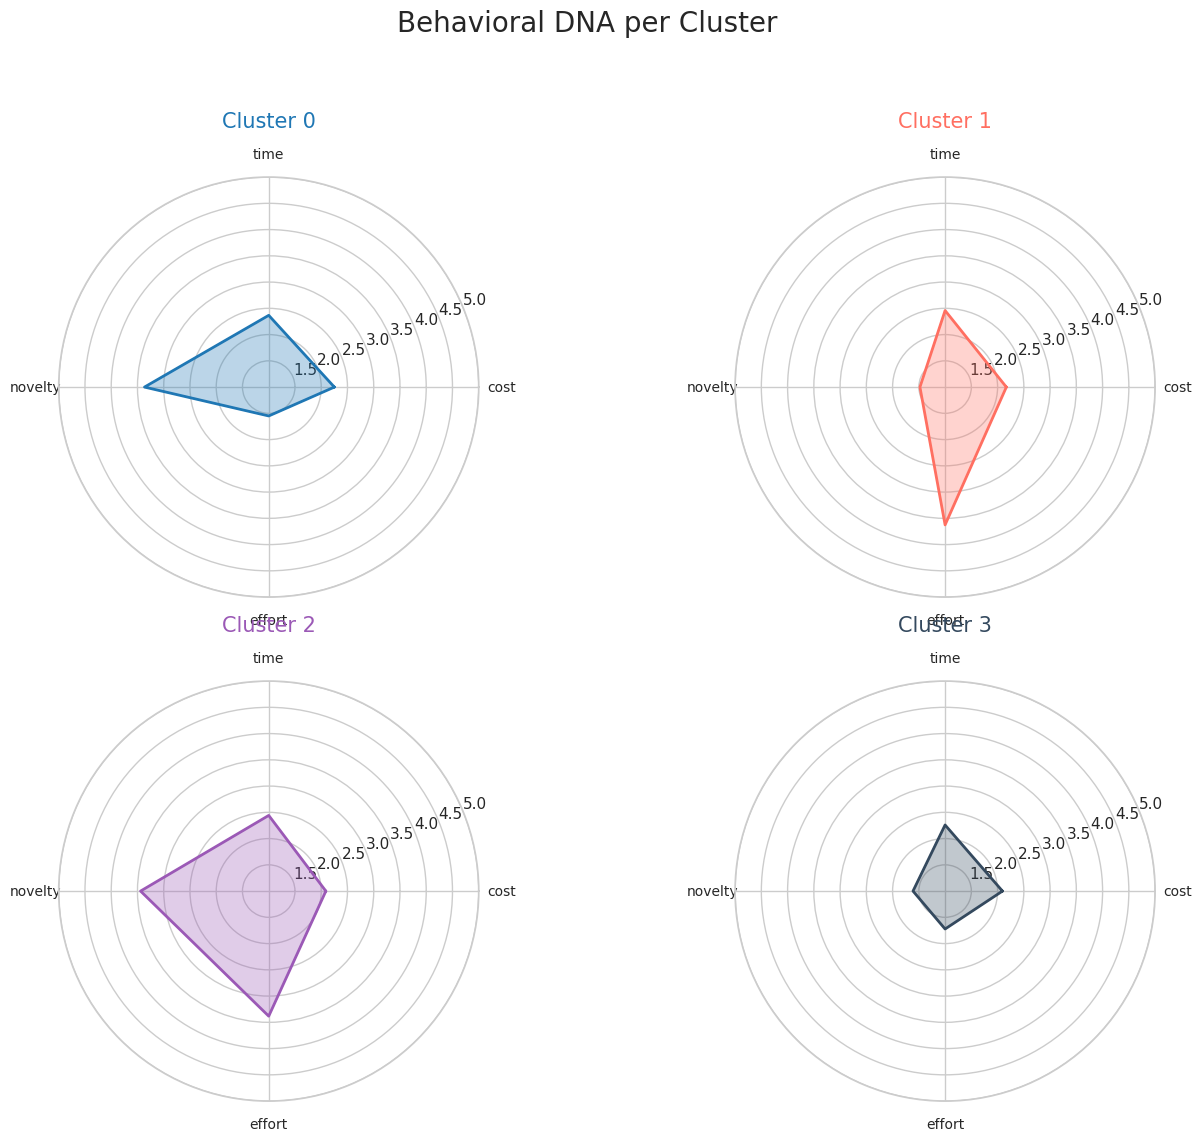

In [12]:
plot_cluster_radar_charts(df_cluster, labels, clustering_cols)

The radar charts summarize the average operational characteristics of each cluster. They provide a descriptive basis for interpreting the activity profiles before examining their distribution across activity types, project contexts, and credibility scores.

| Cluster   | Cost         | Time       | Novelty      | Effort          | Interpretation                                                                              |
| --------- | ------------ | ---------- | ------------ | --------------- | ------------------------------------------------------------------------------------------- |
| Cluster 0 | Low (1–2)    | Low (1–2)  | Low (1–2)    | Low (1–2)       | Routine, standardized activities with minimal overall workload                              |
| Cluster 1 | Medium (2–3) | High (3–5) | Low (1–2)    | Medium (2–3)    | Time-intensive execution and coordination activities                                        |
| Cluster 2 | Variable     | Variable   | High (3–5)   | High (4–5)      | Innovative and adaptive activities with high cognitive complexity                           |
| Cluster 3 | High (3–5)   | High (3–5) | Medium (2–3) | Very High (4–5) | Resource-heavy, complex delivery activities requiring significant human and material effort |


### Number of Activities by Cluster

In [13]:
#Remove warnings
warnings.filterwarnings("ignore")

df_activity["Cluster"] = labels

cluster_counts = df_activity["Cluster"].value_counts().sort_index()

print("\n" + "="*60 + "\n")
print("Number of activities per cluster")
print("\n")
print(cluster_counts)
print("\n" + "="*60 + "\n")



Number of activities per cluster


Cluster
0    60
1    48
2    34
3    54
Name: count, dtype: int64




The four clusters contain between 34 and 60 activities, indicating a relatively balanced distribution of observations. None of the clusters dominates the dataset, allowing each operational profile to be examined in the subsequent descriptive analyses.

### Cluster Distribution within each Activity Type (%)

In [14]:

df_activity["Cluster"] = labels

activity_cluster_dist = (
    pd.crosstab(df_activity["activity_type"], df_activity["Cluster"], normalize="index") * 100
).round(2)

print("\n" + "="*60 + "\n")
print("Cluster distribution within each activity type (%)")
print("\n")
print(activity_cluster_dist)

print("\n" + "="*60 + "\n")



Cluster distribution within each activity type (%)


Cluster                     0      1      2      3
activity_type                                     
Coaching                50.00   0.00  50.00   0.00
Document Analysis        5.13  53.85   5.13  35.90
Document Writing        28.21  20.51  30.77  20.51
Focus Group             25.00  12.50  31.25  31.25
Forum                   50.00  50.00   0.00   0.00
Interview               11.76  29.41  11.76  47.06
Mapping                 25.00  25.00  50.00   0.00
Observation             87.50  12.50   0.00   0.00
Presentation            61.76   8.82   2.94  26.47
Survey                   0.00   0.00  66.67  33.33
Technical Assistance   100.00   0.00   0.00   0.00
Technical Development   42.86  14.29  14.29  28.57
Training                20.00   0.00  40.00  40.00
Workshop                22.22  27.78  22.22  27.78




The distribution varies across activity types. Some activities are concentrated within a single cluster, whereas others are spread across several clusters. These differences suggest that certain activity types exhibit more homogeneous operational characteristics, while others show greater variation within the simulated dataset. Because some activity types contain relatively few observations, these results should be interpreted as descriptive rather than inferential.

### Cluster Distribution within Project Class × Activity Type (%)

In [15]:

df_activity["Cluster"] = labels

cluster_distribution = (
    pd.crosstab(
        [df_activity["project_class"], df_activity["activity_type"]],
        df_activity["Cluster"],
        normalize="index"
    ) * 100
).round(2)

print("\n" + "="*60 + "\n")

print("Cluster distribution within Project Class × Activity Type (%)")

print("\n")

print(cluster_distribution)

print("\n" + "="*60 + "\n")




Cluster distribution within Project Class × Activity Type (%)


Cluster                                           0       1       2      3
project_class         activity_type                                       
External - Behavioral Document Analysis        0.00  100.00    0.00   0.00
                      Document Writing        33.33    0.00   33.33  33.33
                      Focus Group              0.00  100.00    0.00   0.00
                      Forum                  100.00    0.00    0.00   0.00
                      Interview                0.00   50.00    0.00  50.00
                      Observation            100.00    0.00    0.00   0.00
                      Presentation            66.67    0.00    0.00  33.33
External - Structural Document Analysis        0.00   42.86    0.00  57.14
                      Document Writing        20.00   60.00   20.00   0.00
                      Focus Group             28.57    0.00   57.14  14.29
                      Interview   

The combined distribution highlights additional variation in operational profiles across project classes and activity types. Some combinations are concentrated within a single cluster, whereas others are distributed across multiple clusters. Given the limited number of observations in several categories, these results should be viewed as descriptive and exploratory rather than as evidence of systematic relationships.

### Evidence Credibility across Activity Clusters

In [16]:
cs_cols = ["CS_cost", "CS_time", "CS_novelty", "CS_effort"]

print("\n" + "="*60 + "\n")
print("Average Evidence Credibility by Cluster")
print("\n")

cluster_cs = (
    df_activity
    .assign(Cluster=labels)
    .groupby("Cluster")[cs_cols]
    .mean()
    .round(2)
)

print(cluster_cs)

print("\n" + "="*60 + "\n")



Average Evidence Credibility by Cluster


         CS_cost  CS_time  CS_novelty  CS_effort
Cluster                                         
0           3.33     1.77        3.07       1.73
1           2.98     1.67        2.96       1.75
2           3.09     1.76        2.88       1.85
3           3.24     1.89        2.80       1.65




Average credibility scores remain relatively similar across the four clusters, with only small differences observed across the evaluated dimensions. Within the simulated dataset, this suggests that the identified operational profiles are not strongly associated with differences in evidence credibility. These results are descriptive and provide additional context for interpreting the activity clusters.

### Cluster Analytical Synthesis

| Cluster   | Operational Profile                                     | Dominant Activity Types                                    | Dominant Project Context                                                                                                                             | Key Insight                                                                                              |
| --------- | ------------------------------------------------------- | ---------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- |
| Cluster 0 | Low intensity, routine and standardized work            | Observation, Presentation, Forum, Technical Assistance     | Mostly External–Behavioral (training, coaching, community-level capacity building) and Internal–Structural (basic internal processes and tools)      | Represents routine execution activities with low complexity across both internal and external settings   |
| Cluster 1 | Moderate intensity, mainly time and coordination driven | Document Analysis, Interviews, Focus Groups                | Mainly External–Structural (studies, diagnostics, intervention design, beneficiary-focused analysis)                                                 | Represents analytical and coordination-heavy work supporting project design and preparation              |
| Cluster 2 | High novelty and high effort, adaptive work             | Survey, Training, Mapping, Technical Development           | Mix of Internal–Behavioral (organizational capacity building) and External–Structural (technical studies and tools for interventions)                | Represents adaptive and knowledge-intensive activities combining internal learning and external analysis |
| Cluster 3 | High complexity and high resource demand                | Interviews, Workshops, Technical Development, Focus Groups | Strong Internal–Structural (organizational systems, tools, processes) and External–Structural (complex intervention design and technical production) | Represents complex, resource-intensive activities involving system design and multi-stakeholder work     |


The clustering analysis provides a descriptive classification of activities according to their operational characteristics within the simulated dataset. Although cluster separation remains moderate, the identified profiles offer a structured way to examine differences in activity intensity, complexity, and resource requirements. This approach can later be applied to empirical data to explore whether similar operational patterns emerge in real-world evaluation contexts.

## 6-Data Export

In [17]:
# Add cluster assignments to the activity dataset
df_activity["Cluster"] = labels

import os

# Define export path
export_path = "/kaggle/working/"
excel_file = "Activity_Clustering_Dataset.xlsx"
excel_path = os.path.join(export_path, excel_file)

# Ensure directory exists
os.makedirs(export_path, exist_ok=True)

# Define dataset to export
tables_to_export = {
    "Activity_Clustering_Dataset": df_activity
}

# Export to Excel
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables_to_export.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

# Validation
print(f"Activity clustering dataset successfully created: {excel_path}")

Activity clustering dataset successfully created: /kaggle/working/Activity_Clustering_Dataset.xlsx
